# Clustering - Grouping Accidents by Severity Profile

Switching away from predicting a label and instead letting the data group
itself. The idea: instead of looking at cost, spill size, injuries etc. one
at a time, cluster incidents on all of them together and see what kinds of
"accident profiles" fall out - without ever telling the algorithm about
injuries or fatalities as a target.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('ggplot')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('pipeline_accidents_features.csv')
df.shape

(2795, 15)

Using the severity-related columns from the feature set - release volume,
cost, recovery rate, shutdown duration, and the evacuation/injury/fatality
flags. Leaving out `Pipeline Type`, `region` and the time features here since
this is about *how bad* an incident was, not *where/when* it happened.

In [3]:
cluster_cols = ['log_net_loss', 'log_all_costs', 'recovery_rate', 'cost_per_barrel',
                'shutdown_duration_hrs', 'has_evacuation', 'has_injury', 'has_fatality']

X = df[cluster_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(2795, 8)

## KMeans - how many clusters

Running the elbow method (inertia) and silhouette score side by side across a range of k.

In [4]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init = 10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

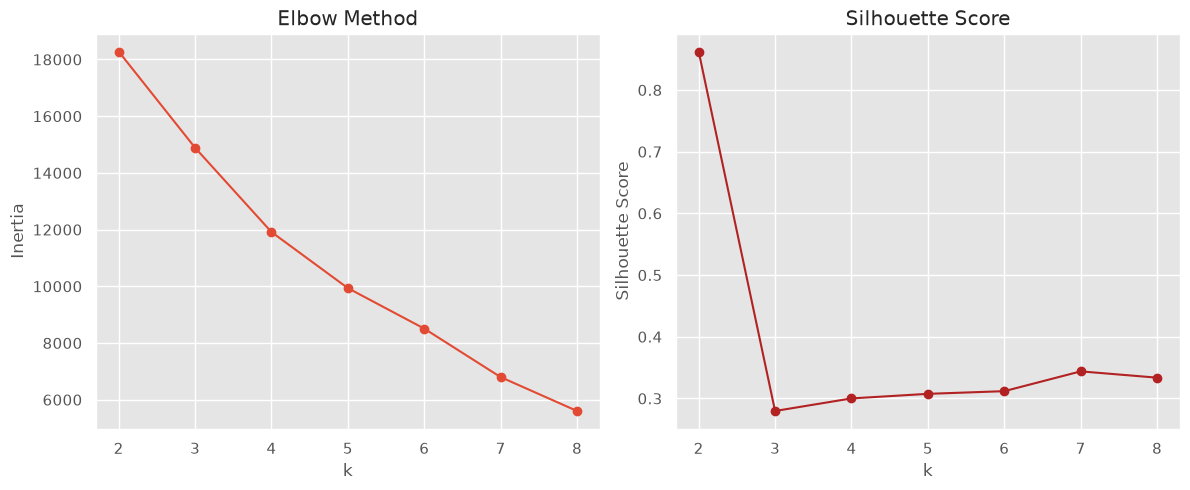

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].plot(list(k_range), inertias, marker = 'o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker = 'o', color = 'firebrick')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

k = 2 technically has the highest silhouette score, but that's because it
just splits off a handful of extreme outliers (8 rows) from everything else -
not a very useful segmentation. The elbow bends around k = 4, and the
silhouette score there is still reasonable, so going with k = 4 for something
that's actually interpretable.

In [6]:
kmeans = KMeans(n_clusters = 4, random_state = RANDOM_STATE, n_init = 10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'].value_counts().sort_index()

kmeans_cluster
0    1430
1       8
2    1306
3      51
Name: count, dtype: int64

## Profiling the clusters

Converting the log-scale columns back to their original units so the profile is easier to read.

In [7]:
df['net_loss_barrels'] = np.expm1(df['log_net_loss'])
df['all_costs'] = np.expm1(df['log_all_costs'])

cluster_profile = df.groupby('kmeans_cluster').agg(
    n = ('kmeans_cluster', 'size'),
    avg_net_loss_barrels = ('net_loss_barrels', 'mean'),
    avg_all_costs = ('all_costs', 'mean'),
    avg_recovery_rate = ('recovery_rate', 'mean'),
    avg_shutdown_hrs = ('shutdown_duration_hrs', 'mean'),
    evacuation_rate = ('has_evacuation', 'mean'),
    injury_rate = ('has_injury', 'mean'),
    fatality_rate = ('has_fatality', 'mean'),
)
cluster_profile

,n,avg_net_loss_barrels,avg_all_costs,avg_recovery_rate,avg_shutdown_hrs,evacuation_rate,injury_rate,fatality_rate
kmeans_cluster,,,,,,,,
0,1430,35.069035,6.146726e+05,0.635292,138.488625,0.00,0.000000,0.0
1,8,4374.312500,2.144384e+06,0.072627,413.947917,0.25,0.750000,1.0
2,1306,122.472496,5.134294e+04,0.180590,26.330947,0.00,0.004594,0.0
3,51,2439.020980,2.682220e+07,0.242693,340.317974,1.00,0.000000,0.0


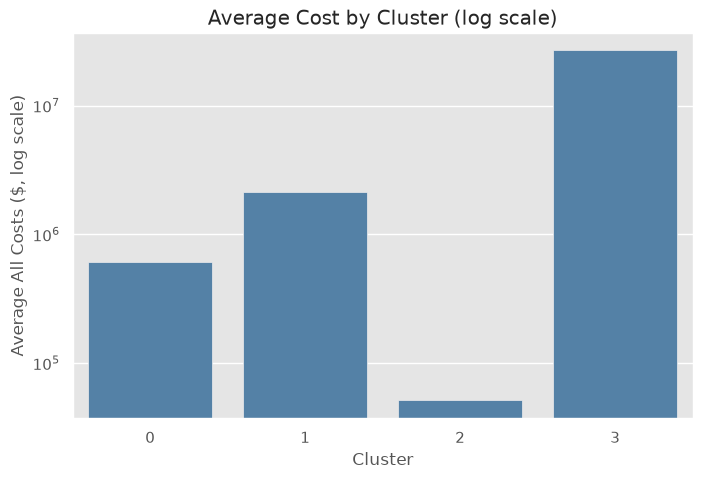

In [8]:
plt.figure(figsize = (8, 5))
sns.barplot(x = cluster_profile.index, y = cluster_profile['avg_all_costs'], color = 'steelblue')
plt.yscale('log')
plt.title('Average Cost by Cluster (log scale)')
plt.xlabel('Cluster')
plt.ylabel('Average All Costs ($, log scale)')
plt.show()

Four fairly distinct profiles fall out, and none of them were told about
injuries/fatalities as a target - they show up purely from clustering on
severity features:

- **Cluster 2** (n ≈ 1306) - small, cheap, routine incidents. Low release
  volume, lowest average cost, short shutdowns, essentially no injuries.
  The "typical" accident in this dataset.
- **Cluster 0** (n ≈ 1430) - moderate incidents with the best recovery rate
  (~64% of released liquid recovered) and longer shutdowns than cluster 2,
  but still no injuries or fatalities.
- **Cluster 3** (n ≈ 51) - large spills with by far the highest average cost
  and 100% evacuation rate, but zero injuries/fatalities - these read like
  big, expensive, disruptive-but-not-deadly environmental/property-damage
  events.
- **Cluster 1** (n = 8) - tiny but the one that matters most: low recovery
  rate, the longest average shutdowns, and a 75% injury / 100% fatality
  rate. This is the "someone got hurt" cluster, and it falls out on its own
  even though the clustering never saw a human-harm label directly - it's
  driven by the *combination* of high release volume, poor recovery, and
  long shutdown.

## Visualizing the clusters

Projecting down to 2D with PCA just to see the cluster separation - the features themselves are 8-dimensional so there's no direct way to plot them.

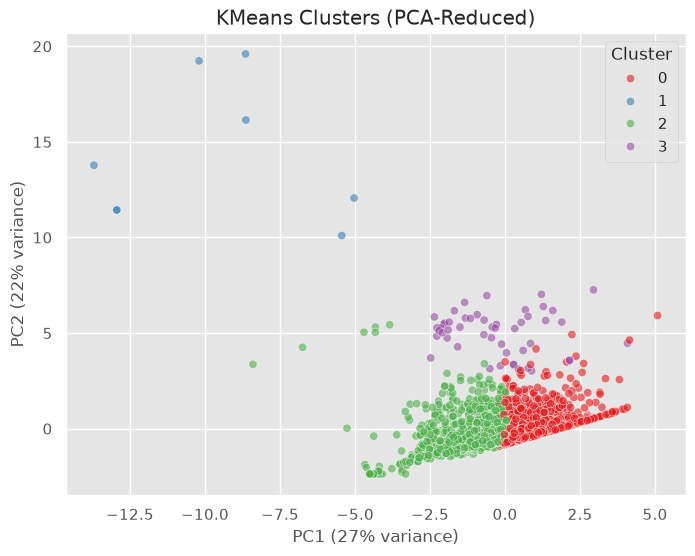

In [9]:
pca = PCA(n_components = 2, random_state = RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize = (8, 6))
sns.scatterplot(x = coords[:, 0], y = coords[:, 1], hue = df['kmeans_cluster'],
                 palette = 'Set1', alpha = 0.6)
plt.title('KMeans Clusters (PCA-Reduced)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
plt.legend(title = 'Cluster')
plt.show()

## DBSCAN - a second clustering algorithm, and a different lens

KMeans forces every point into a cluster and assumes roughly round,
similarly-sized groups. DBSCAN doesn't - it groups points that are densely
packed together and explicitly labels anything that doesn't fit as noise,
which is actually a nice way to think about "unusual" incidents. Picking
`eps` using a k-distance plot (distance to the 5th nearest neighbor for
every point, sorted) - the point where the curve kicks upward is a
reasonable `eps`.

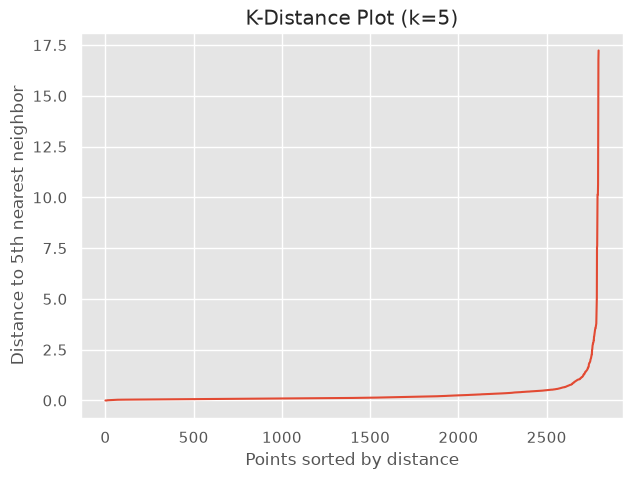

In [10]:
neighbors = NearestNeighbors(n_neighbors = 5).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize = (7, 5))
plt.plot(k_distances)
plt.title('K-Distance Plot (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 5th nearest neighbor')
plt.show()

In [11]:
dbscan = DBSCAN(eps = 1.0, min_samples = 5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()
print(f"clusters found: {n_clusters}")
print(f"noise points: {n_noise} ({n_noise / len(df):.1%} of the data)")

clusters found: 3
noise points: 97 (3.5% of the data)


In [12]:
overall_rates = df[['has_injury', 'has_fatality', 'has_evacuation']].mean()
noise_rates = df.loc[df['dbscan_cluster'] == -1, ['has_injury', 'has_fatality', 'has_evacuation']].mean()

pd.DataFrame({'overall': overall_rates, 'dbscan_noise_points': noise_rates})

,overall,dbscan_noise_points
has_injury,0.004293,0.123711
has_fatality,0.002862,0.082474
has_evacuation,0.018962,0.329897


This is the interesting part - the incidents DBSCAN flags as noise (not
belonging to any dense cluster) have injury and fatality rates roughly 29x
the dataset average, and an evacuation rate about 17x the average. Without
ever seeing an injury/fatality label, density-based clustering essentially
rediscovers "the severe, unusual incidents" as the points that don't fit the
normal pattern - which lines up well with KMeans cluster 1 from earlier.

In [13]:
pd.crosstab(df['kmeans_cluster'], df['dbscan_cluster'])

dbscan_cluster,-1,0,1,2
kmeans_cluster,,,,
0,42,1388,0,0
1,8,0,0,0
2,17,1289,0,0
3,30,0,5,16


All 8 of KMeans's "someone got hurt" cluster show up as DBSCAN noise, along
with about 60% of the large-spill cluster (3) - the two algorithms mostly
agree on which incidents are unusual, even though they work in completely
different ways (centroid distance vs local density). That agreement is a
decent sanity check that these aren't artifacts of one particular method.